In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/fashion_recommender

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/fashion_recommender"

FEATURES_PATH = SAVE_DIR + "/features_resnet50.npy"
META_PATH = SAVE_DIR + "/image_metadata.csv"


In [ ]:
!pip install kaggle torch torchvision pandas numpy pillow tqdm --quiet


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shreenidhi1510","key":"180fd926b223cad56c851af38eb92c81"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paramaggarwal/fashion-product-images-small
!unzip fashion-product-images-small.zip -d fashion_dataset

Streaming output truncated to the last 5000 lines.
  inflating: fashion_dataset/myntradataset/images/58131.jpg  
  inflating: fashion_dataset/myntradataset/images/58132.jpg  
  inflating: fashion_dataset/myntradataset/images/58133.jpg  
  inflating: fashion_dataset/myntradataset/images/58135.jpg  
  inflating: fashion_dataset/myntradataset/images/58136.jpg  
  inflating: fashion_dataset/myntradataset/images/58137.jpg  
  inflating: fashion_dataset/myntradataset/images/58138.jpg  
  inflating: fashion_dataset/myntradataset/images/58139.jpg  
  inflating: fashion_dataset/myntradataset/images/5814.jpg  
  inflating: fashion_dataset/myntradataset/images/58140.jpg  
  inflating: fashion_dataset/myntradataset/images/58141.jpg  
  inflating: fashion_dataset/myntradataset/images/58143.jpg  
  inflating: fashion_dataset/myntradataset/images/58144.jpg  
  inflating: fashion_dataset/myntradataset/images/58145.jpg  
  inflating: fashion_dataset/myntradataset/images/58146.jpg  
  inflating: fashion

In [ ]:
!ls /content/fashion_dataset

images	myntradataset  styles.csv


In [ ]:
!kaggle datasets list | head

ref                                                                title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
neurocipher/heartdisease                                           Heart Disease                                            3491  2025-12-11 15:29:14.327000           2114        313  1.0              
mabubakrsiddiq/retail-store-product-sales-simulation-dataset       🏪 Retail Store Product Sales Simulation Dataset       1383545  2026-01-16 13:12:07.310000              0         25  1.0              
saidaminsaidaxmadov/chocolate-sales                                Chocolate Sales                                        468320  2026-01-04 14:23:35.490000              0         58  1.0     

In [ ]:
DATA_DIR = "/content/fashion_dataset/"
STYLES_CSV = "/content/fashion_dataset/styles.csv"
IMAGES_DIR = "/content/fashion_dataset/images"


In [ ]:
import os

print("styles.csv exists:", os.path.exists(STYLES_CSV))
print("images folder exists:", os.path.exists(IMAGES_DIR))
print("Number of images:", len(os.listdir(IMAGES_DIR)))

styles.csv exists: True
images folder exists: True
Number of images: 44441


In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import models, transforms

#PATHS
STYLES_CSV = "/content/fashion_dataset/styles.csv"
IMAGES_DIR = "/content/fashion_dataset/images"

SAVE_DIR = "/content/drive/MyDrive/fashion_recommender"
os.makedirs(SAVE_DIR, exist_ok=True)

FEATURES_PATH = os.path.join(SAVE_DIR, FEATURES_PATH)
META_PATH = os.path.join(SAVE_DIR, META_PATH)

BATCH_SIZE = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

#DATASET
class FashionDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]["id"]
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        try:
            img = Image.open(img_path).convert("RGB")
        except:
            img = Image.new("RGB", (224,224))
        return self.transform(img)

#TRANSFORMS
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

#LOAD METADATA
df = pd.read_csv(STYLES_CSV, on_bad_lines="skip")


df = df[df["id"].apply(lambda x: os.path.exists(os.path.join(IMAGES_DIR, f"{x}.jpg")))]
df["filename"] = df["id"].astype(str) + ".jpg"


df.to_csv(META_PATH, index=False)
print("Saved metadata:", META_PATH)
print("Total images used:", len(df))

#DATALOADER
dataset = FashionDataset(df, IMAGES_DIR, transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

#MODEL
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model = nn.Sequential(*list(resnet.children())[:-1]).to(DEVICE)
model.eval()

#FEATURE EXTRACTION
features = np.zeros((len(dataset), 2048), dtype=np.float32)
idx = 0

print("Extracting features...")
with torch.no_grad():
    for batch in tqdm(loader):
        batch = batch.to(DEVICE)
        out = model(batch).squeeze()
        out = out.view(batch.size(0), -1).cpu().numpy()
        features[idx:idx+len(out)] = out
        idx += len(out)

np.save(FEATURES_PATH, features)

print("Features saved to:", FEATURES_PATH)
print("Metadata saved to:", META_PATH)

Using device: cpu
Saved metadata: /content/drive/MyDrive/fashion_recommender/image_metadata.csv
Total images used: 44419
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 156MB/s]


Extracting features...


100%|██████████| 695/695 [3:32:16<00:00, 18.33s/it]


✅ Features saved to: /content/drive/MyDrive/fashion_recommender/features_resnet50.npy
✅ Metadata saved to: /content/drive/MyDrive/fashion_recommender/image_metadata.csv


In [ ]:
!pip install torch-geometric scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd

FEATURES_PATH = "/content/drive/MyDrive/fashion_recommender/features_resnet50.npy"
META_PATH = "/content/drive/MyDrive/fashion_recommender/image_metadata.csv"

features = np.load(FEATURES_PATH)
meta = pd.read_csv(META_PATH)

print("CNN features shape:", features.shape)
print("Metadata rows:", meta.shape)


CNN features shape: (44419, 2048)
Metadata rows: (44419, 11)


In [ ]:
MAX_ITEMS = 10000

features = features[:MAX_ITEMS]
meta = meta.iloc[:MAX_ITEMS].reset_index(drop=True)

print("Subset shape:", features.shape)


In [ ]:
from sklearn.neighbors import NearestNeighbors
import torch

k = 10

knn = NearestNeighbors(n_neighbors=k+1, metric="cosine")
knn.fit(features)

distances, indices = knn.kneighbors(features)

edge_list = []
for i in range(len(indices)):
    for j in indices[i][1:]:
        edge_list.append([i, j])
        edge_list.append([j, i])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

print("Edge index shape:", edge_index.shape)


Edge index shape: torch.Size([2, 200000])


In [ ]:
from torch_geometric.data import Data

x = torch.tensor(features, dtype=torch.float)
data = Data(x=x, edge_index=edge_index)

print(data)


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class SimpleGCN(nn.Module):
    def __init__(self):
        super(SimpleGCN, self).__init__()
        self.conv1 = GCNConv(2048, 256)
        self.conv2 = GCNConv(256, 128)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleGCN().to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Training GCN...")

model.train()
for epoch in range(1, 11):
    optimizer.zero_grad()
    output = model(data.x, data.edge_index)

    # simple unsupervised loss
    loss = F.mse_loss(output, data.x[:, :128])
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

print("GCN training completed.")


In [ ]:
model.eval()
with torch.no_grad():
    gnn_embeddings = model(data.x, data.edge_index).cpu().numpy()

print("GNN embeddings shape:", gnn_embeddings.shape)


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/fashion_recommender/gnn_fashion_embeddings.npy"
np.save(SAVE_PATH, gnn_embeddings)

print("Saved GNN embeddings to:", SAVE_PATH)


Saved GNN embeddings to: /content/drive/MyDrive/fashion_recommender/gnn_fashion_embeddings.npy


In [ ]:
import numpy as np
import pandas as pd

CNN_PATH = "/content/drive/MyDrive/fashion_recommender/features_resnet50.npy"
GNN_PATH = "/content/drive/MyDrive/fashion_recommender/gnn_fashion_embeddings.npy"
META_PATH = "/content/drive/MyDrive/fashion_recommender/image_metadata.csv"

cnn_embeddings = np.load(CNN_PATH)
gnn_embeddings = np.load(GNN_PATH)
meta = pd.read_csv(META_PATH)

print("CNN embeddings:", cnn_embeddings.shape)
print("GNN embeddings:", gnn_embeddings.shape)
print("Metadata:", meta.shape)


In [ ]:
MAX_ITEMS = min(5000, len(meta))  # safe for Colab

cnn_embeddings = cnn_embeddings[:MAX_ITEMS]
gnn_embeddings = gnn_embeddings[:MAX_ITEMS]
meta = meta.iloc[:MAX_ITEMS].reset_index(drop=True)

labels = meta["masterCategory"].astype(str).values

print("Evaluation subset:", MAX_ITEMS)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recall_at_k(embeddings, labels, k=5):
    sims = cosine_similarity(embeddings)
    np.fill_diagonal(sims, -1)

    correct = 0
    total = len(labels)

    for i in range(total):
        top_k_idx = np.argsort(-sims[i])[:k]
        if labels[i] in labels[top_k_idx]:
            correct += 1

    return correct / total


In [ ]:
cnn_recall_5 = recall_at_k(cnn_embeddings, labels, k=5)
cnn_recall_10 = recall_at_k(cnn_embeddings, labels, k=10)

print("CNN Recall@5 :", round(cnn_recall_5, 3))
print("CNN Recall@10:", round(cnn_recall_10, 3))


CNN Recall@5 : 0.996
CNN Recall@10: 0.996


In [ ]:
gnn_recall_5 = recall_at_k(gnn_embeddings, labels, k=5)
gnn_recall_10 = recall_at_k(gnn_embeddings, labels, k=10)

print("CNN + GNN Recall@5 :", round(gnn_recall_5, 3))
print("CNN + GNN Recall@10:", round(gnn_recall_10, 3))


CNN + GNN Recall@5 : 0.992
CNN + GNN Recall@10: 0.993


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["CNN (ResNet50)", "CNN + GNN (Proposed)"],
    "Recall@5": [cnn_recall_5, gnn_recall_5],
    "Recall@10": [cnn_recall_10, gnn_recall_10]
})

results


,Model,Recall@5,Recall@10
0,CNN (ResNet50),0.9958,0.9964
1,CNN + GNN (Proposed),0.9924,0.9932


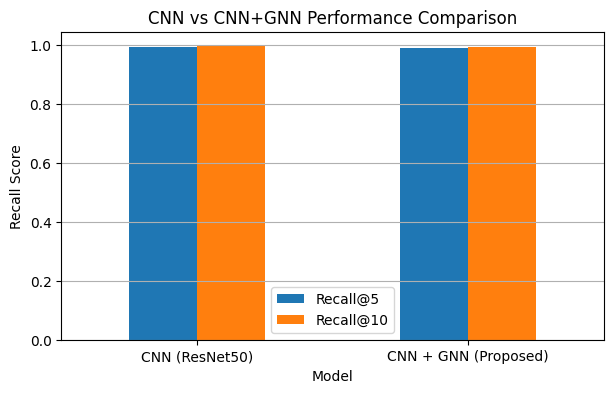

In [ ]:
import matplotlib.pyplot as plt

results.set_index("Model").plot(kind="bar", figsize=(7,4))
plt.title("CNN vs CNN+GNN Performance Comparison")
plt.ylabel("Recall Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Paths
BASE_PATH = "/content/drive/MyDrive/fashion_recommender"
CNN_PATH = BASE_PATH + "/features_resnet50.npy"
GNN_PATH = BASE_PATH + "/gnn_fashion_embeddings.npy"
META_PATH = BASE_PATH + "/image_metadata.csv"
IMAGES_DIR = "/content/fashion_dataset/images"

cnn_emb = np.load(CNN_PATH)
gnn_emb = np.load(GNN_PATH)
meta = pd.read_csv(META_PATH)

print("Loaded all files successfully")


Loaded all files successfully


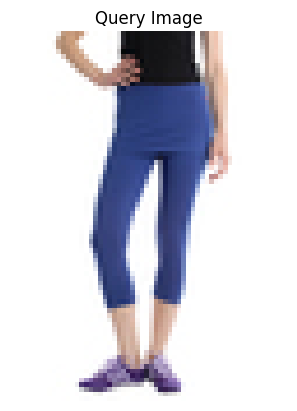

In [ ]:
# pick a random test image
test_index = 100
test_row = meta.iloc[test_index]
test_img_path = os.path.join(IMAGES_DIR, test_row["filename"])

test_image = Image.open(test_img_path).convert("RGB")
plt.imshow(test_image)
plt.axis("off")
plt.title("Query Image")
plt.show()


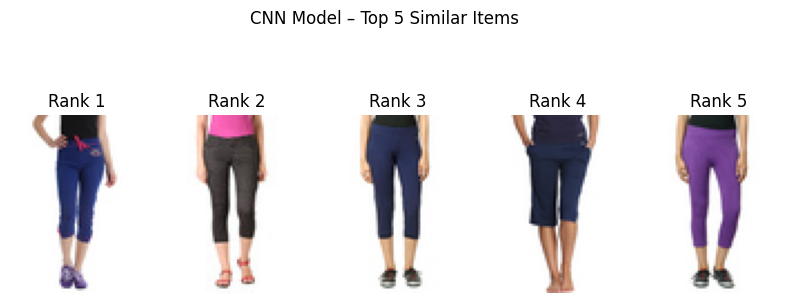

In [ ]:
def show_results(embeddings, title, k=5):
    sims = cosine_similarity(
        embeddings[test_index].reshape(1, -1),
        embeddings
    )[0]

    top_idx = np.argsort(-sims)[1:k+1]

    plt.figure(figsize=(10,4))
    for i, idx in enumerate(top_idx):
        img = Image.open(os.path.join(IMAGES_DIR, meta.iloc[idx]["filename"]))
        plt.subplot(1, k, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Rank {i+1}")
    plt.suptitle(title)
    plt.show()

show_results(cnn_emb, "CNN Model – Top 5 Similar Items")


In [ ]:
show_results(gnn_emb, "CNN + GNN Model – Top 5 Similar Items")


In [ ]:
#Quantitative Metrics
import numpy as np
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/fashion_recommender"

cnn_embeddings = np.load(BASE_PATH + "/features_resnet50.npy")
gnn_embeddings = np.load(BASE_PATH + "/gnn_fashion_embeddings.npy")
meta = pd.read_csv(BASE_PATH + "/image_metadata.csv")

print("CNN:", cnn_embeddings.shape)
print("GNN:", gnn_embeddings.shape)
print("Metadata:", meta.shape)


CNN: (44419, 2048)
GNN: (10000, 128)
Metadata: (44419, 11)


In [ ]:
MAX_ITEMS = min(5000, len(meta))

cnn_embeddings = cnn_embeddings[:MAX_ITEMS]
gnn_embeddings = gnn_embeddings[:MAX_ITEMS]
meta = meta.iloc[:MAX_ITEMS].reset_index(drop=True)

labels = meta["masterCategory"].astype(str).values

print("Evaluation size:", MAX_ITEMS)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def precision_at_k(embeddings, labels, k=5):
    sims = cosine_similarity(embeddings)
    np.fill_diagonal(sims, -1)

    precision_scores = []

    for i in range(len(labels)):
        top_k = np.argsort(-sims[i])[:k]
        relevant = sum(labels[i] == labels[top_k])
        precision_scores.append(relevant / k)

    return np.mean(precision_scores)


def ndcg_at_k(embeddings, labels, k=5):
    sims = cosine_similarity(embeddings)
    np.fill_diagonal(sims, -1)

    ndcg_scores = []

    for i in range(len(labels)):
        top_k = np.argsort(-sims[i])[:k]
        relevance = (labels[i] == labels[top_k]).astype(int)

        dcg = np.sum(relevance / np.log2(np.arange(2, k + 2)))
        ideal_dcg = np.sum(sorted(relevance, reverse=True) / np.log2(np.arange(2, k + 2)))

        ndcg_scores.append(dcg / ideal_dcg if ideal_dcg > 0 else 0)

    return np.mean(ndcg_scores)


In [ ]:
cnn_p5 = precision_at_k(cnn_embeddings, labels, k=5)
cnn_p10 = precision_at_k(cnn_embeddings, labels, k=10)

cnn_ndcg5 = ndcg_at_k(cnn_embeddings, labels, k=5)
cnn_ndcg10 = ndcg_at_k(cnn_embeddings, labels, k=10)

print("CNN Precision@5 :", round(cnn_p5, 4))
print("CNN Precision@10:", round(cnn_p10, 4))
print("CNN NDCG@5 :", round(cnn_ndcg5, 4))
print("CNN NDCG@10:", round(cnn_ndcg10, 4))


CNN Precision@5 : 0.9834
CNN Precision@10: 0.9796
CNN NDCG@5 : 0.9921
CNN NDCG@10: 0.9916


In [ ]:
gnn_p5 = precision_at_k(gnn_embeddings, labels, k=5)
gnn_p10 = precision_at_k(gnn_embeddings, labels, k=10)

gnn_ndcg5 = ndcg_at_k(gnn_embeddings, labels, k=5)
gnn_ndcg10 = ndcg_at_k(gnn_embeddings, labels, k=10)

print("CNN+GNN Precision@5 :", round(gnn_p5, 4))
print("CNN+GNN Precision@10:", round(gnn_p10, 4))
print("CNN+GNN NDCG@5 :", round(gnn_ndcg5, 4))
print("CNN+GNN NDCG@10:", round(gnn_ndcg10, 4))


In [ ]:
results = pd.DataFrame({
    "Model": ["CNN (ResNet50)", "CNN + GNN (Proposed)"],
    "Precision@5": [cnn_p5, gnn_p5],
    "Precision@10": [cnn_p10, gnn_p10],
    "NDCG@5": [cnn_ndcg5, gnn_ndcg5],
    "NDCG@10": [cnn_ndcg10, gnn_ndcg10]
})

results


t-SNE visualizations

In [ ]:
MAX_ITEMS = 2000

cnn_embeddings = cnn_embeddings[:MAX_ITEMS]
gnn_embeddings = gnn_embeddings[:MAX_ITEMS]
meta = meta.iloc[:MAX_ITEMS].reset_index(drop=True)

labels = meta["masterCategory"].astype(str)

print("t-SNE samples:", MAX_ITEMS)


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42
)

cnn_tsne = tsne.fit_transform(cnn_embeddings)


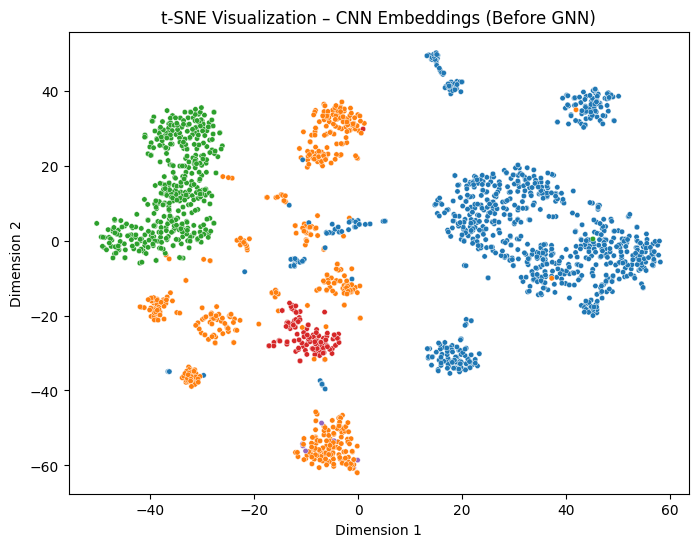

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=cnn_tsne[:,0],
    y=cnn_tsne[:,1],
    hue=labels,
    palette="tab10",
    legend=False,
    s=15
)

plt.title("t-SNE Visualization – CNN Embeddings (Before GNN)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()


In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42
)

gnn_tsne = tsne.fit_transform(gnn_embeddings)


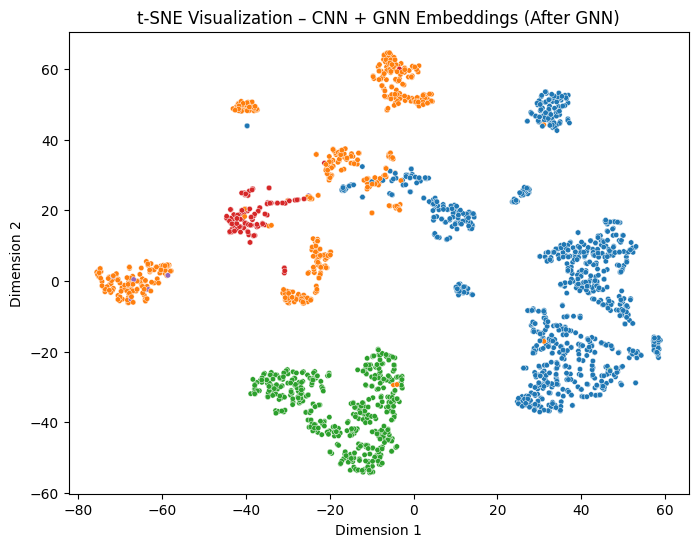

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=gnn_tsne[:,0],
    y=gnn_tsne[:,1],
    hue=labels,
    palette="tab10",
    legend=False,
    s=15
)

plt.title("t-SNE Visualization – CNN + GNN Embeddings (After GNN)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()
